In [1]:
import pandas as pd

data = pd.read_csv('../Dataset/Scored_Cleaned_Data.csv')

In [2]:
x = data.drop(columns=["Monthly_Spend"])
y = data["Monthly_Spend"]

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.model_selection import KFold

def evaluate_spectral_custom_logic(df, target_col='Risk_score', n_folds=5):
    X_df = df.drop(columns=["Timestamp", "Group"], errors='ignore')
    spend_values = df[target_col].values

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    overall_results = []

    print(f"{'K':<5} | {'Avg Silhouette':<15} | {'Custom Deviation':<20}")
    print("-" * 50)

    for k in range(3, 20):
        fold_silhouettes = []
        fold_custom_deviations = []

        for train_idx, val_idx in kf.split(X_df):
            X_fold = X_df.iloc[train_idx]
            spend_fold = spend_values[train_idx]

            model = SpectralClustering(n_clusters=k, affinity='nearest_neighbors',
                                       random_state=42, n_init=10)
            labels = model.fit_predict(X_fold)

            # Silhouette
            try:
                sil = silhouette_score(X_fold, labels)
            except:
                sil = 0
            fold_silhouettes.append(sil)

            # (sum(|M - means|^0.5))^2
            cluster_means = [spend_fold[labels == cid].mean() for cid in np.unique(labels) if np.any(labels == cid)]
            c_means = np.array(cluster_means)
            M = np.mean(c_means)
            diffs = np.abs(M - c_means)
            custom_dev = (np.sum(diffs**0.5))**2
            fold_custom_deviations.append(custom_dev)

        avg_sil = np.mean(fold_silhouettes)
        avg_dev = np.mean(fold_custom_deviations)
        overall_results.append({'k': k, 'Silhouette': avg_sil, 'Custom_Deviation': avg_dev})
        print(f"{k:<5} | {avg_sil:<15.4f} | {avg_dev:<20.2f}")

    return pd.DataFrame(overall_results)

spectral_custom_results = evaluate_spectral_custom_logic(data)

K     | Avg Silhouette  | Custom Deviation    
--------------------------------------------------


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_emb

3     | 0.0536          | 231.55              


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


4     | 0.0430          | 478.42              


...

8     | 0.2049          | 1925.62             


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_emb

9     | 0.2340          | 2084.13             


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


10    | 0.2467          | 2740.30             


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


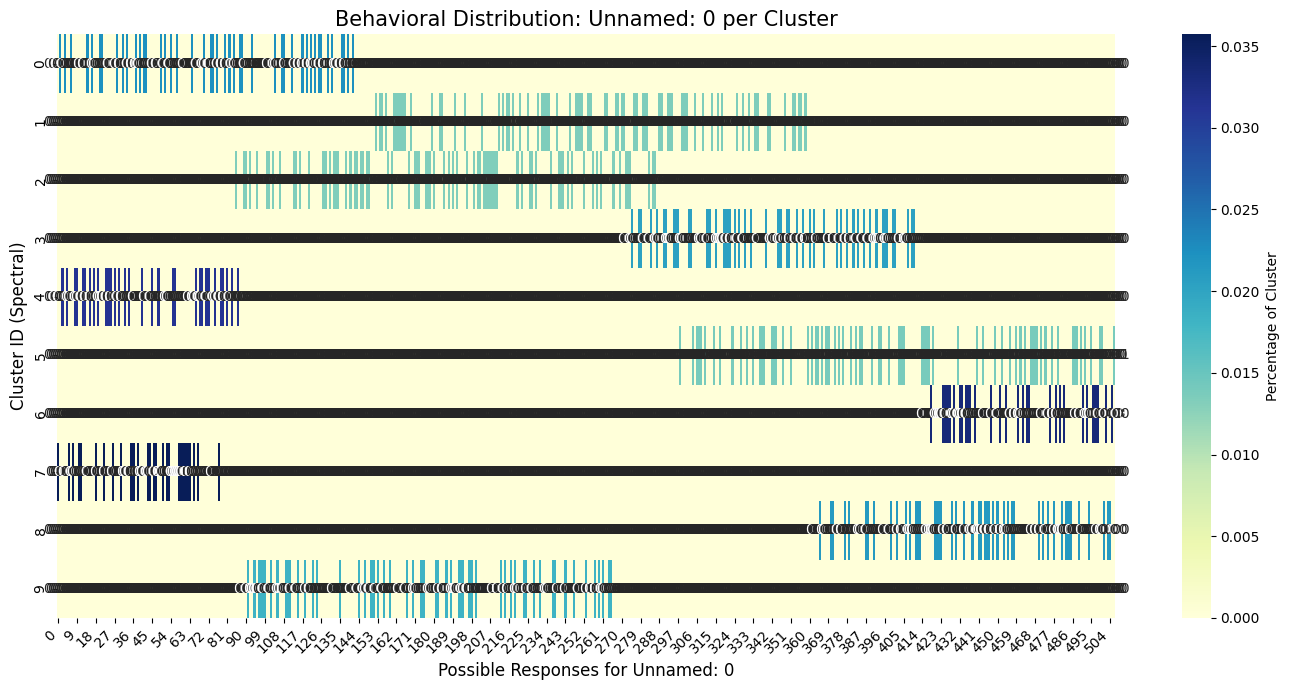

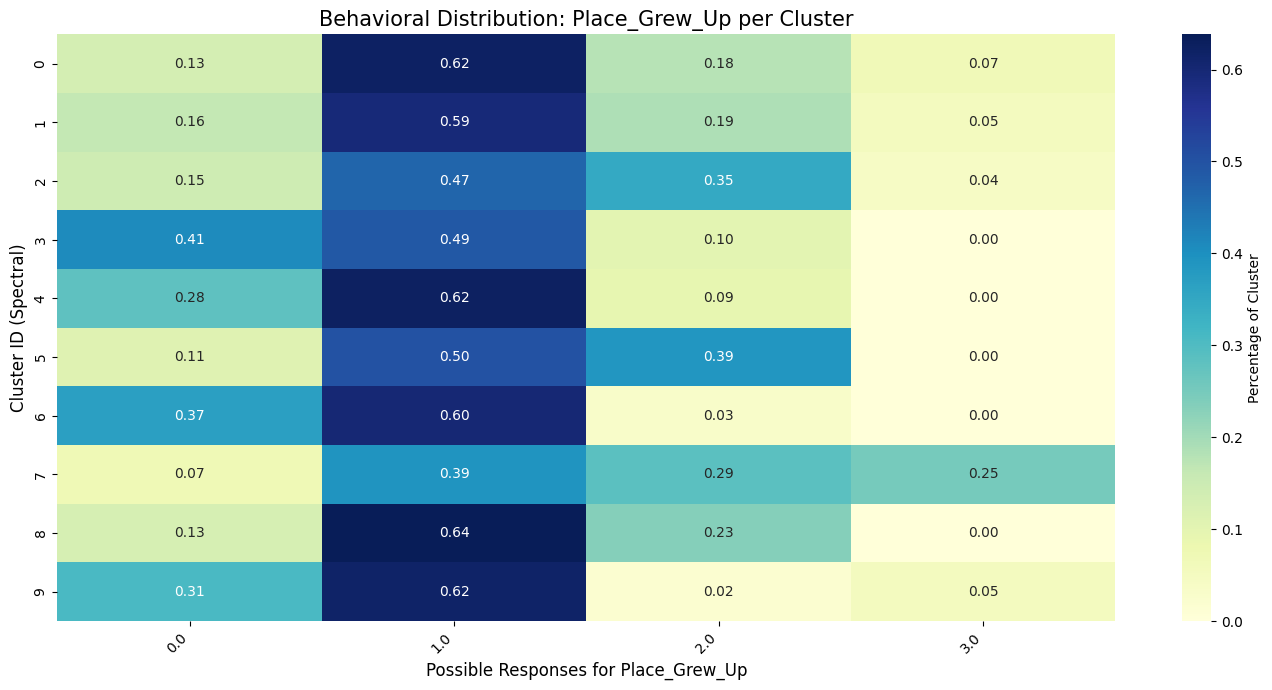

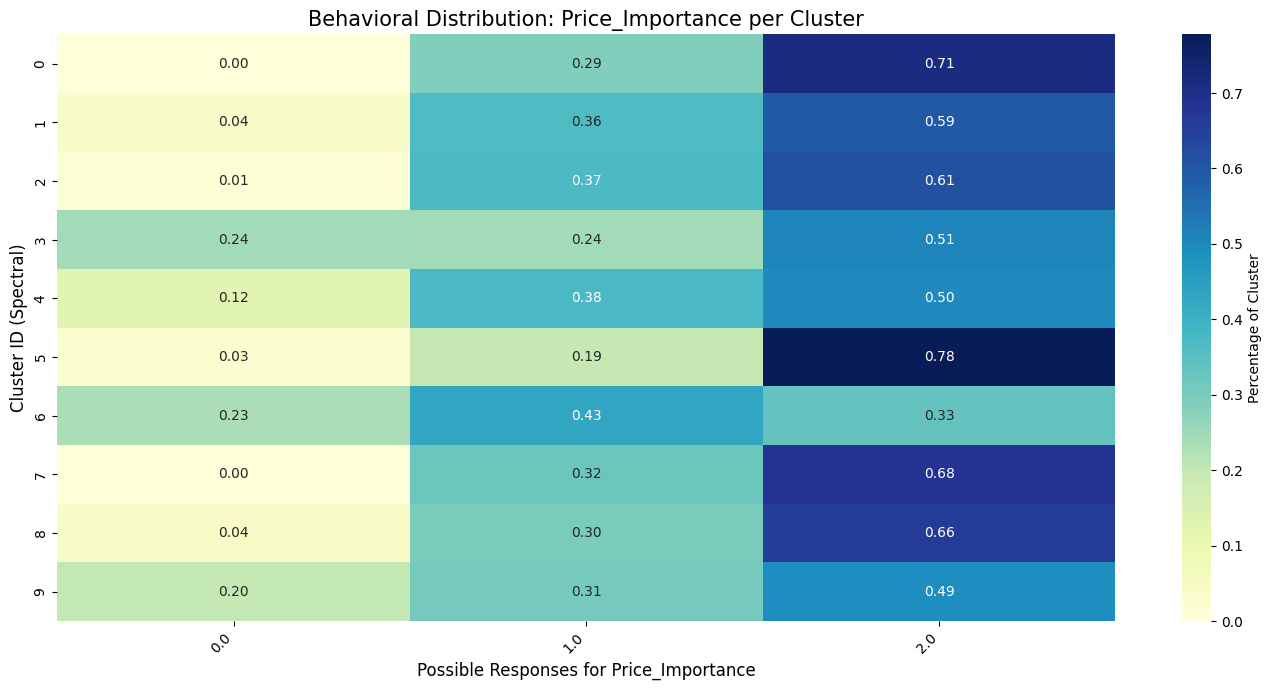

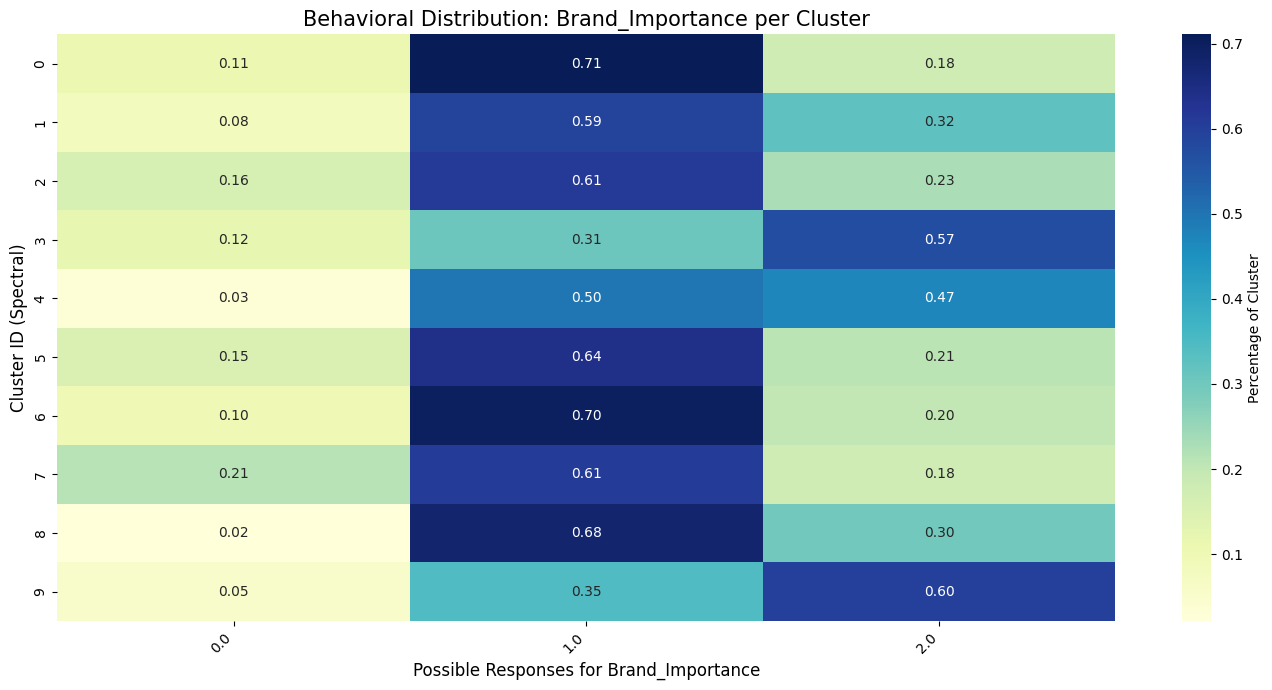

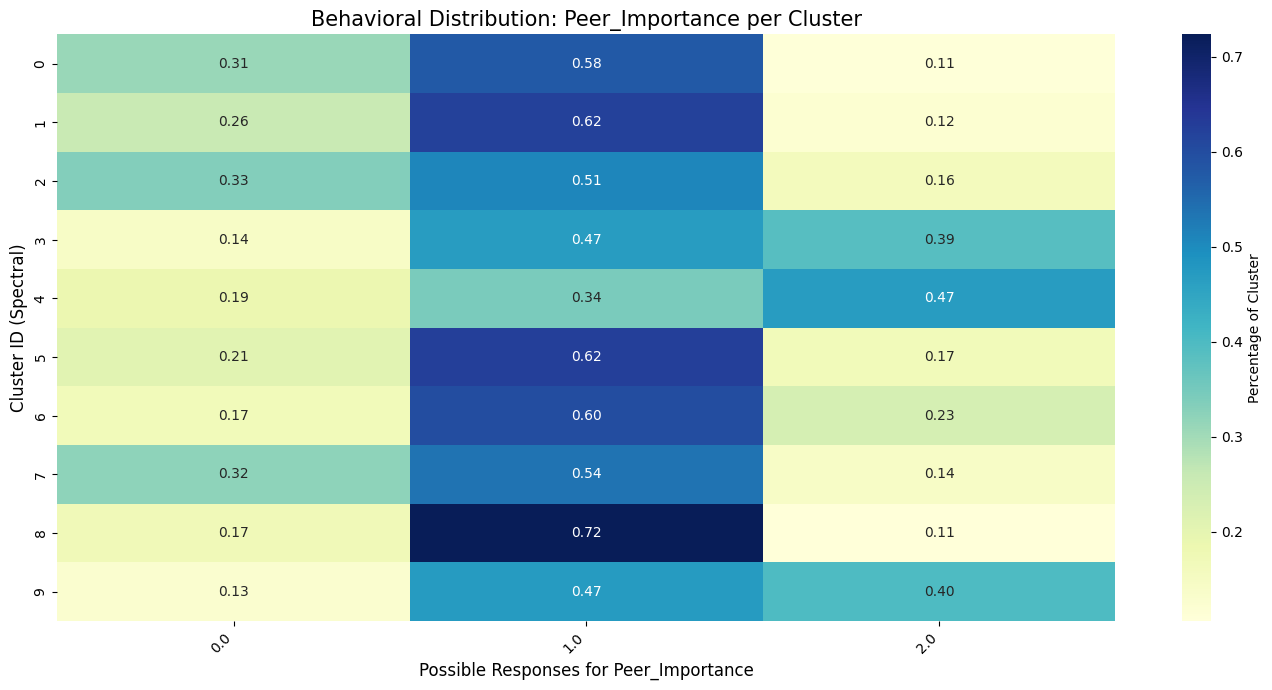

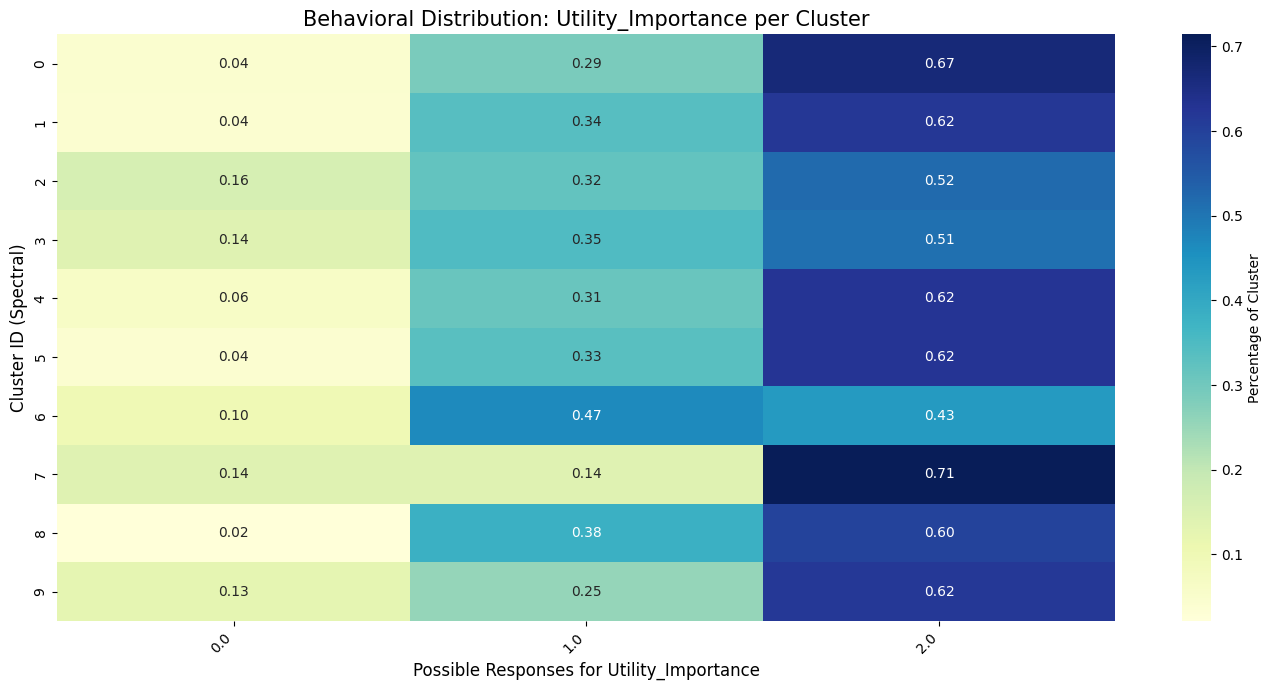

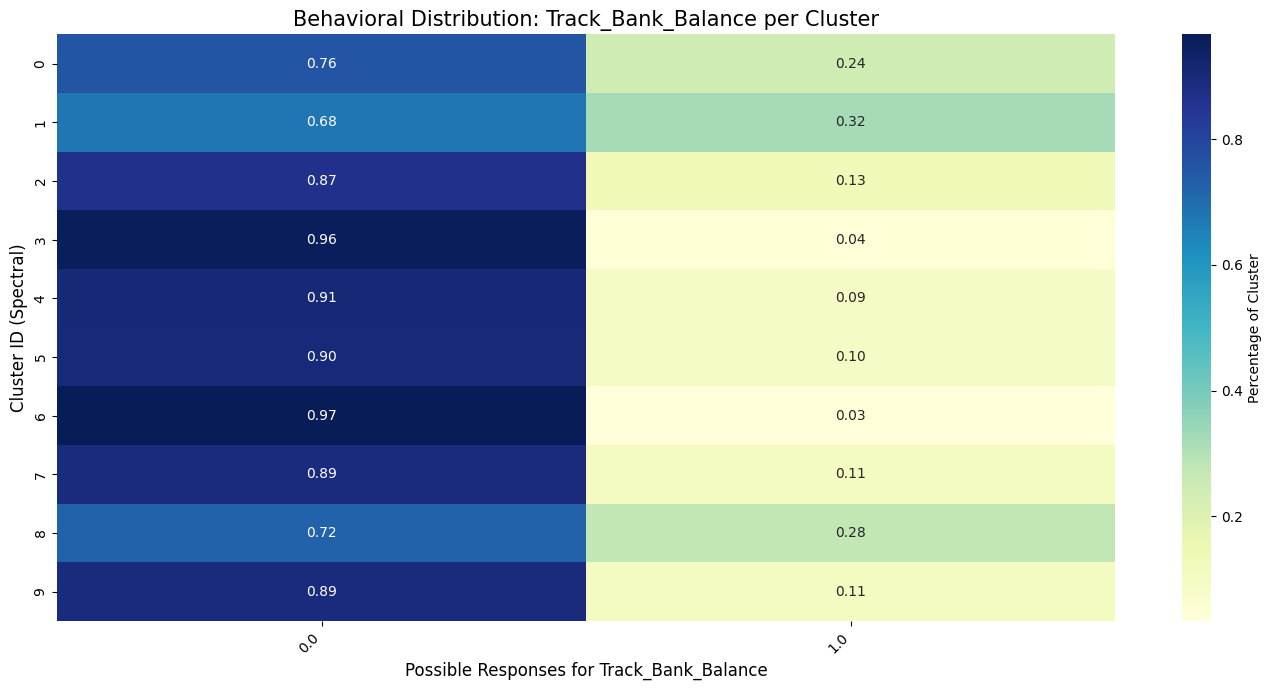

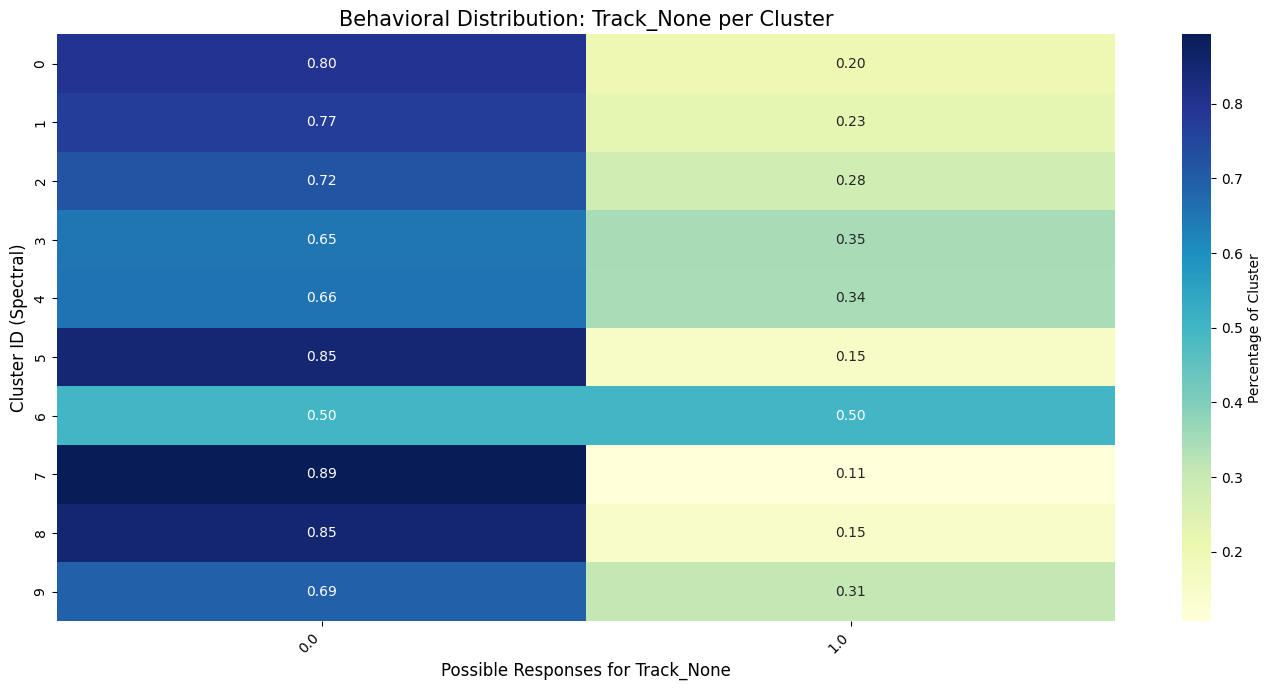

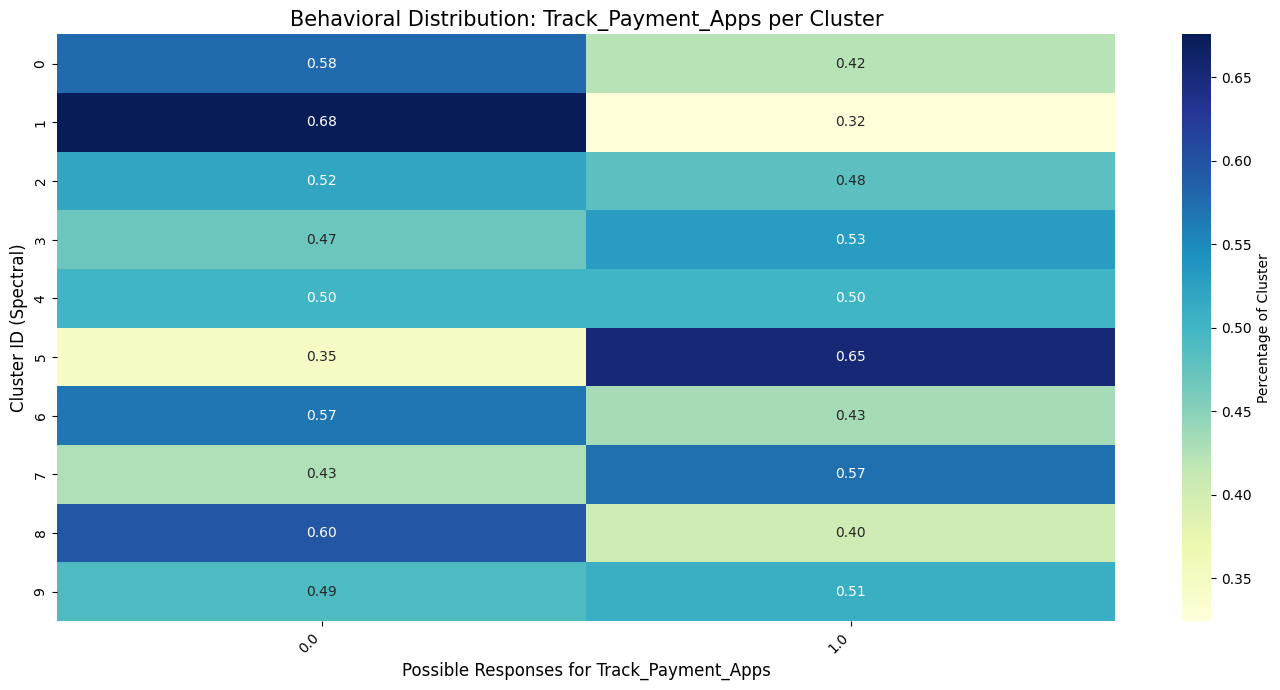

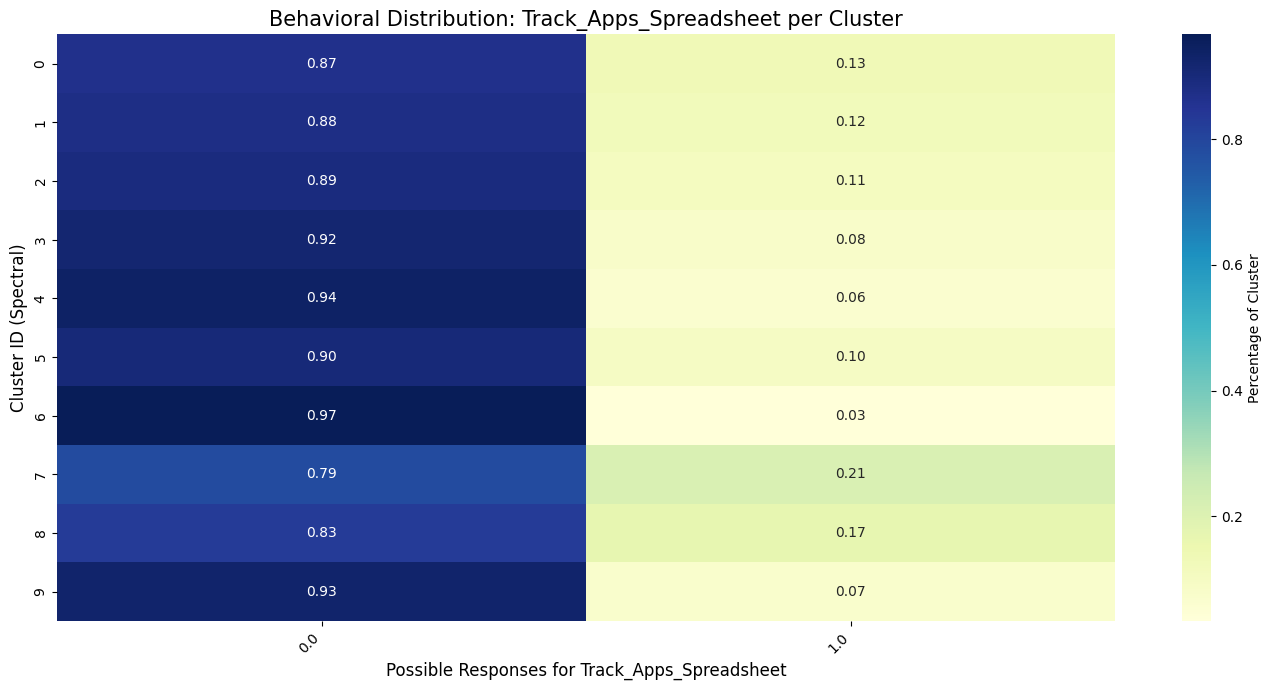

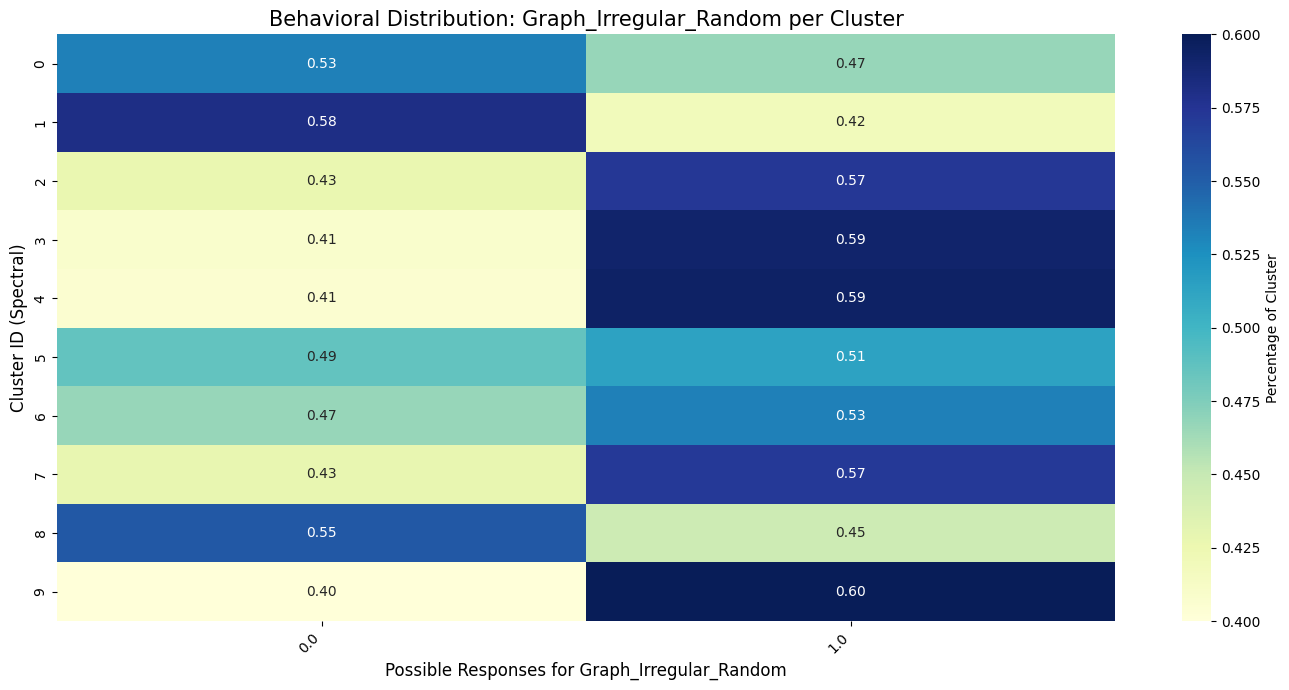

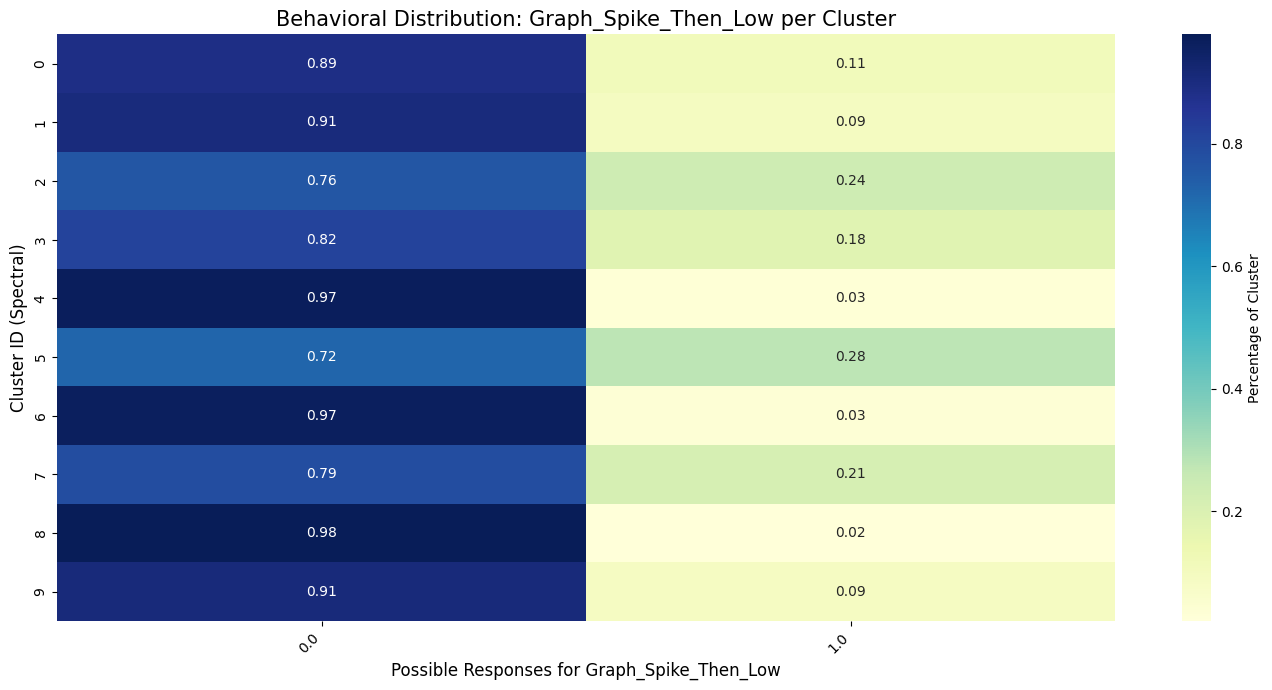

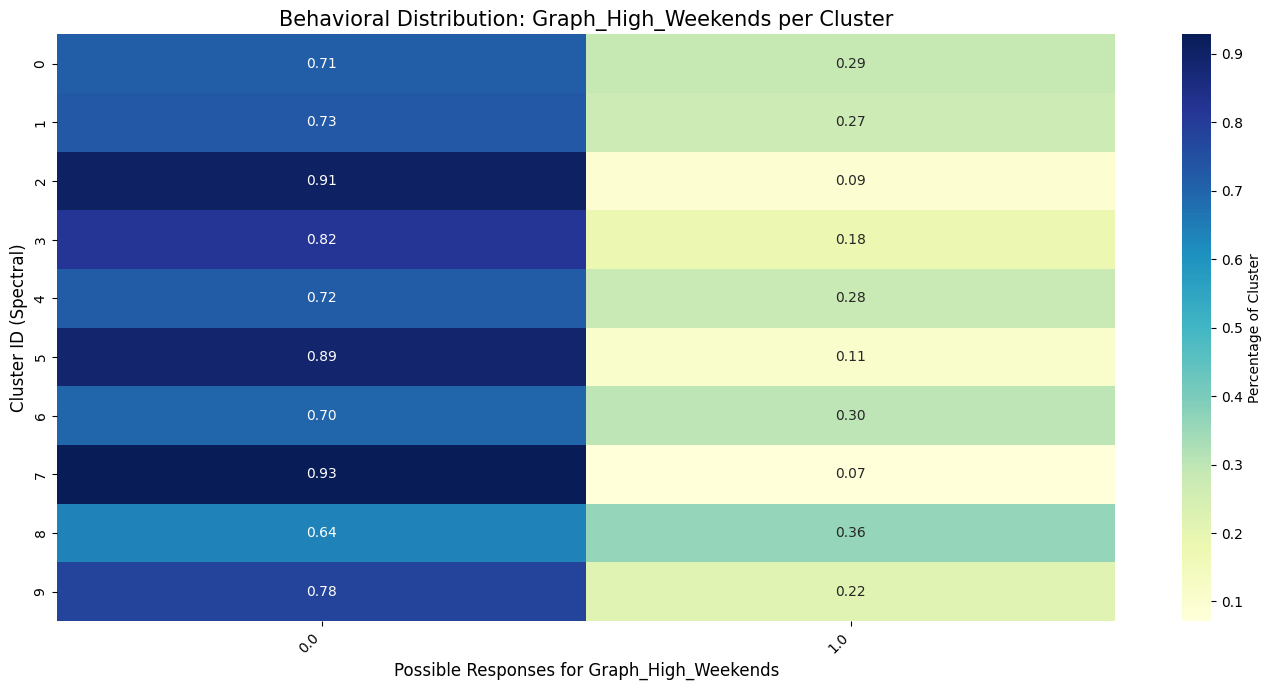

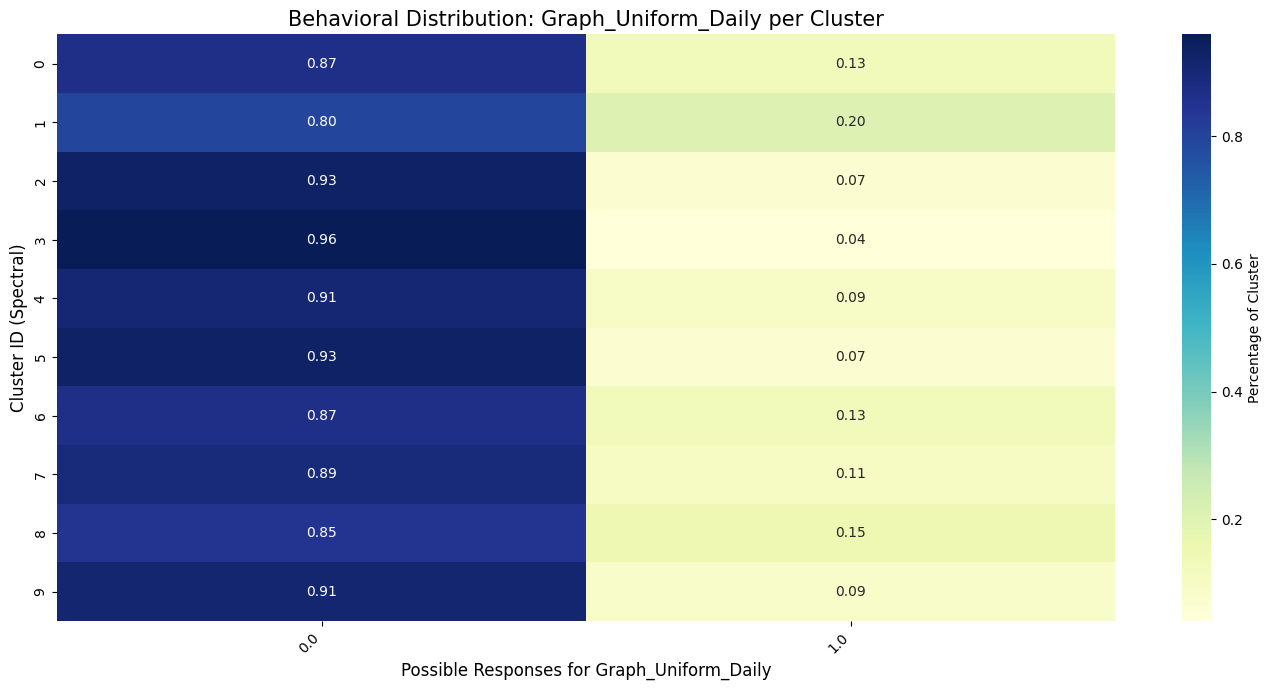

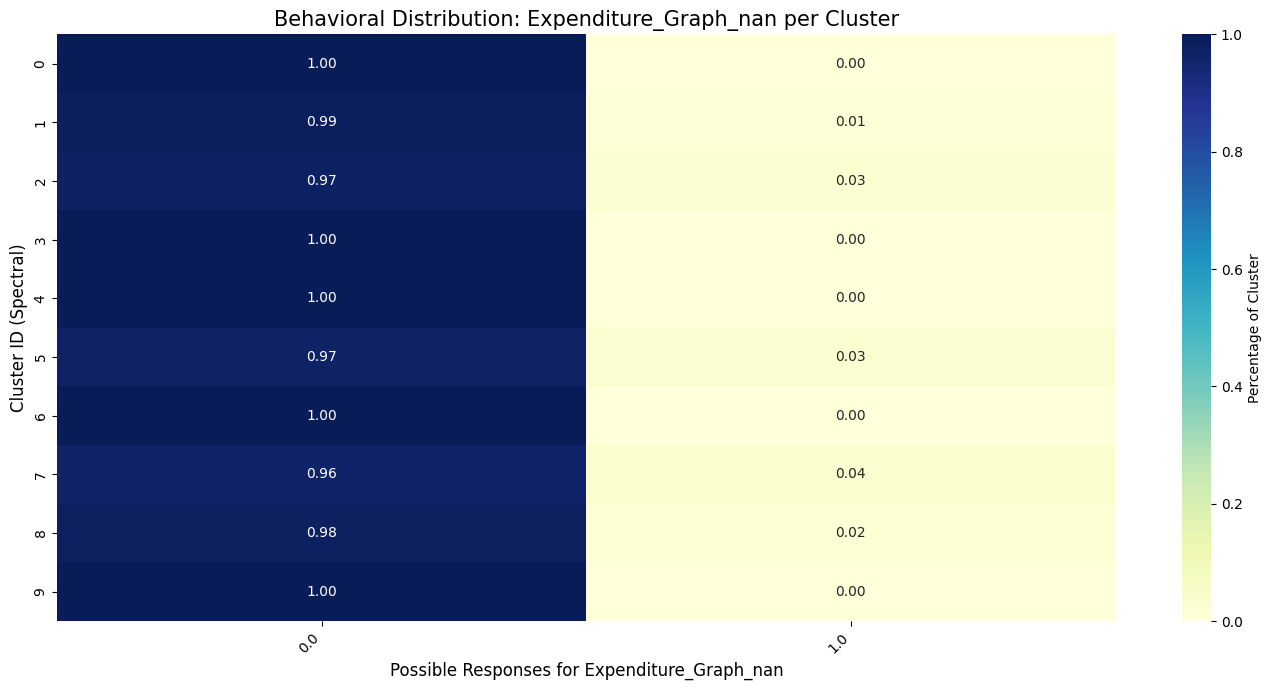

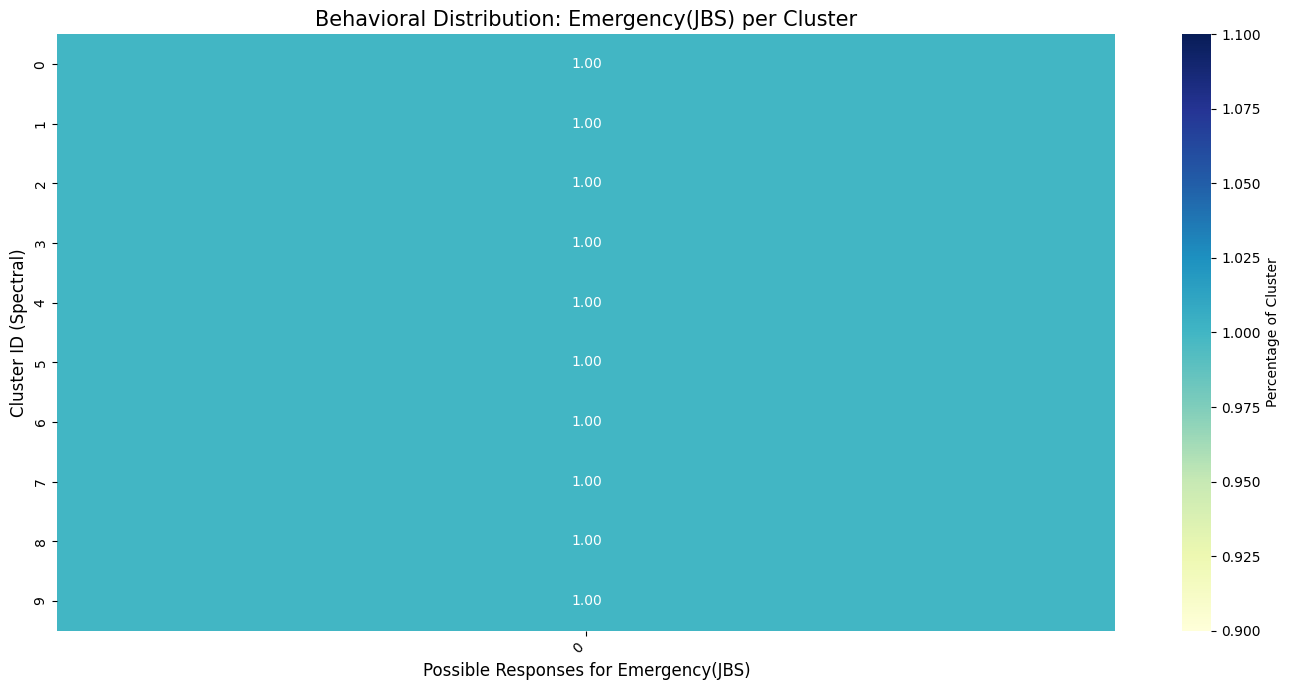

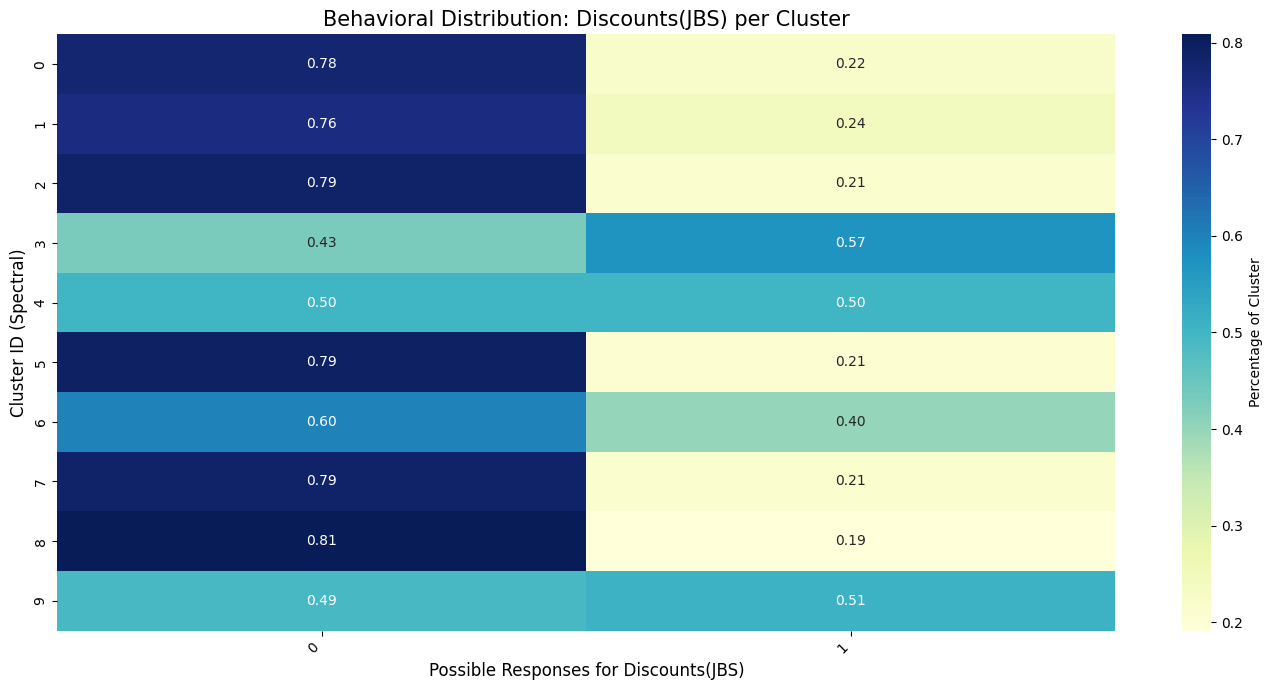

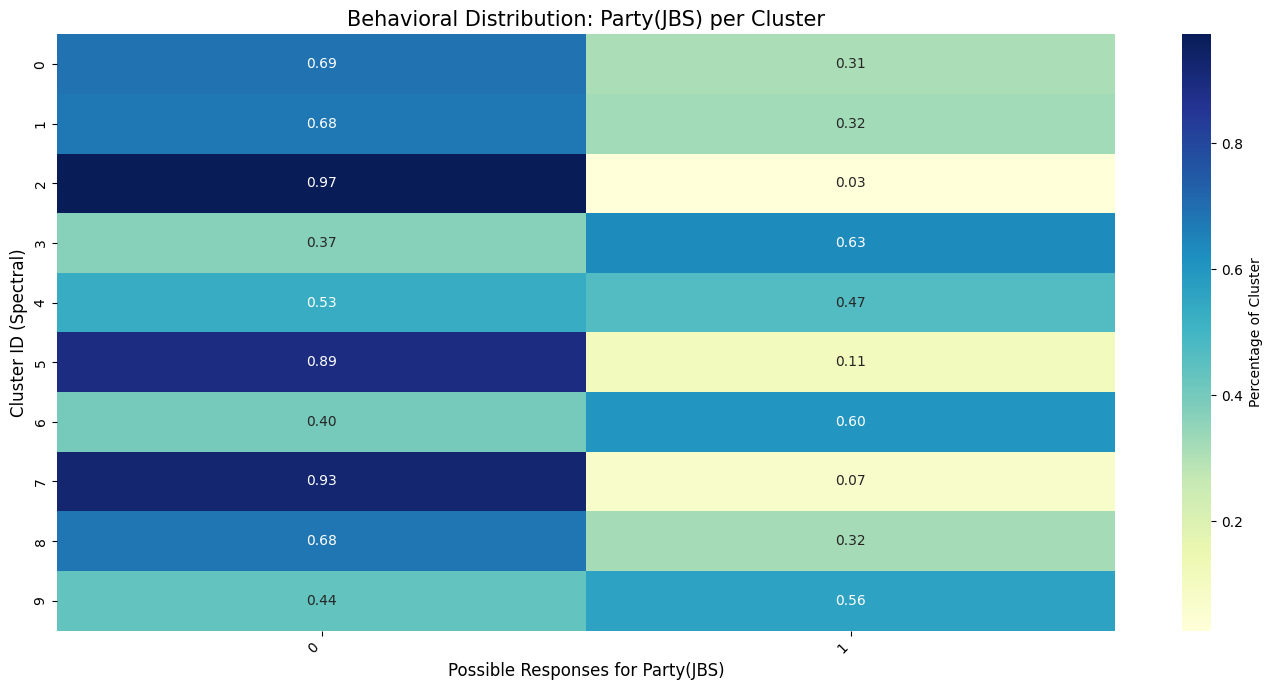

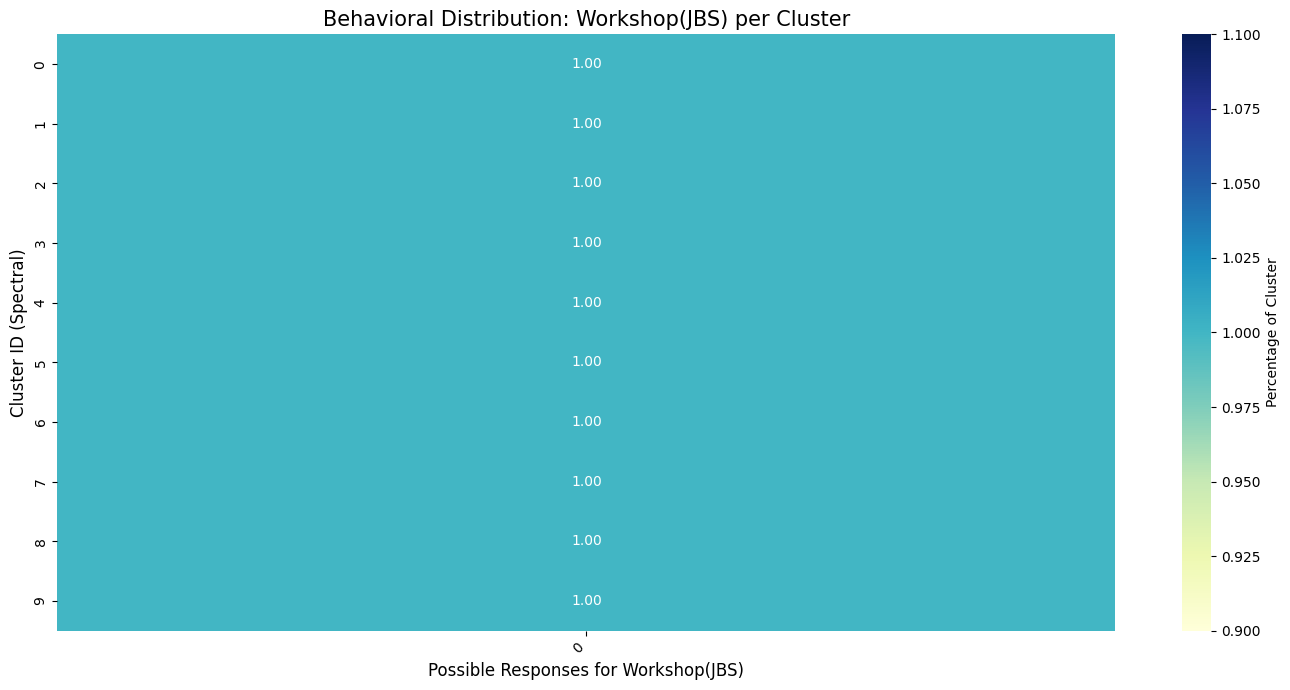

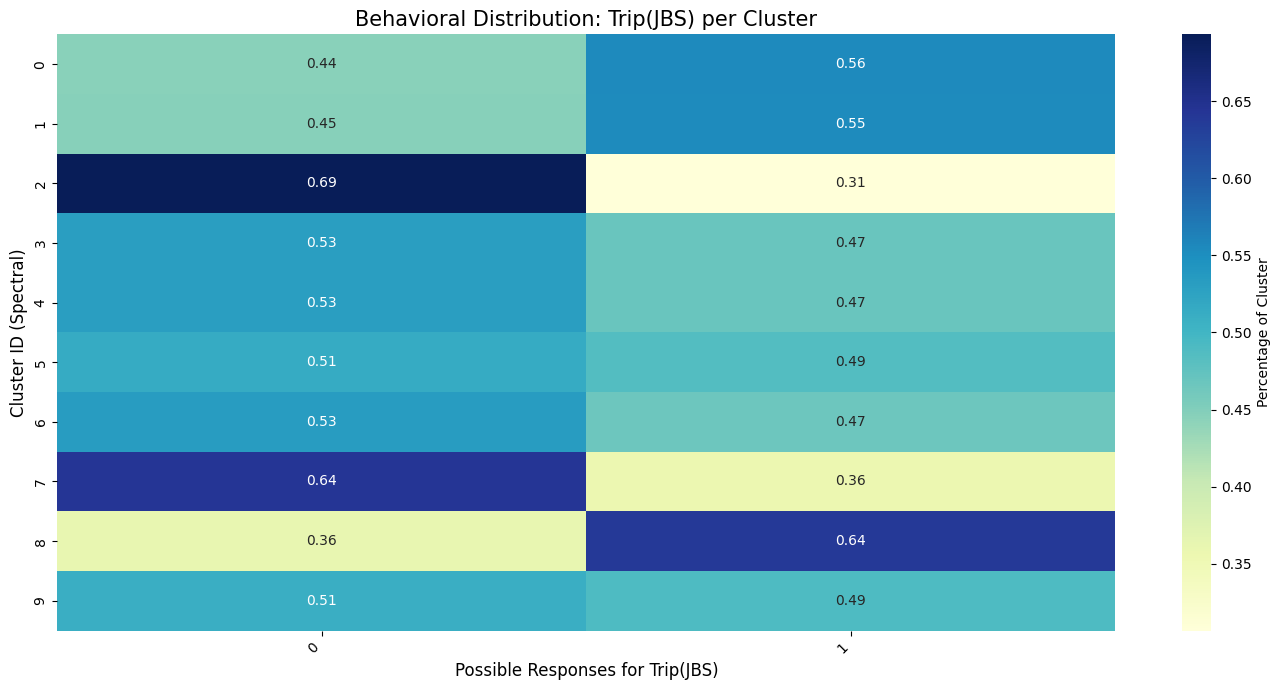

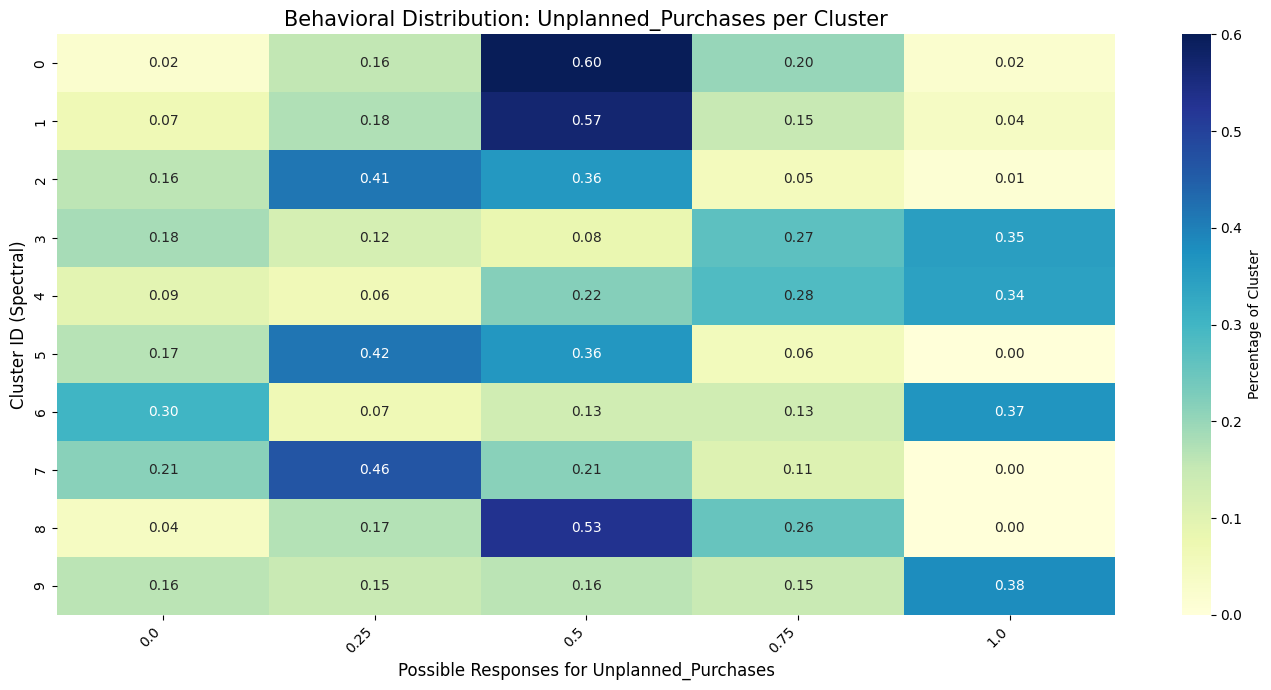

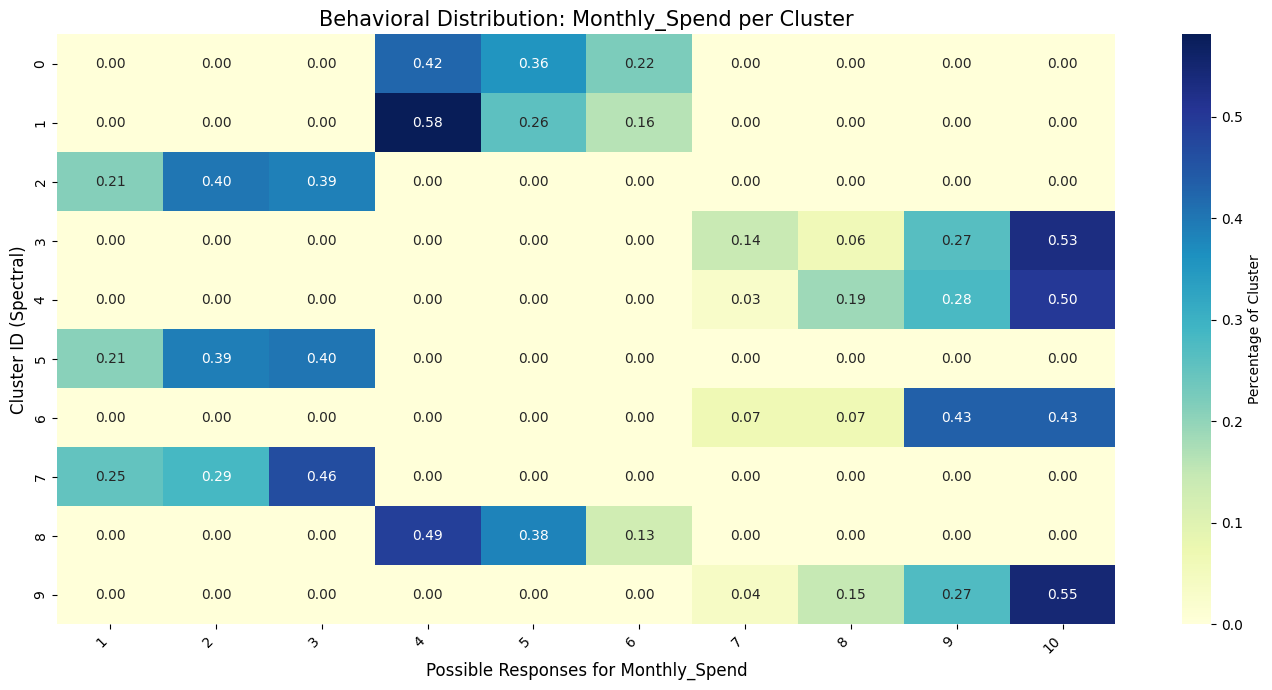

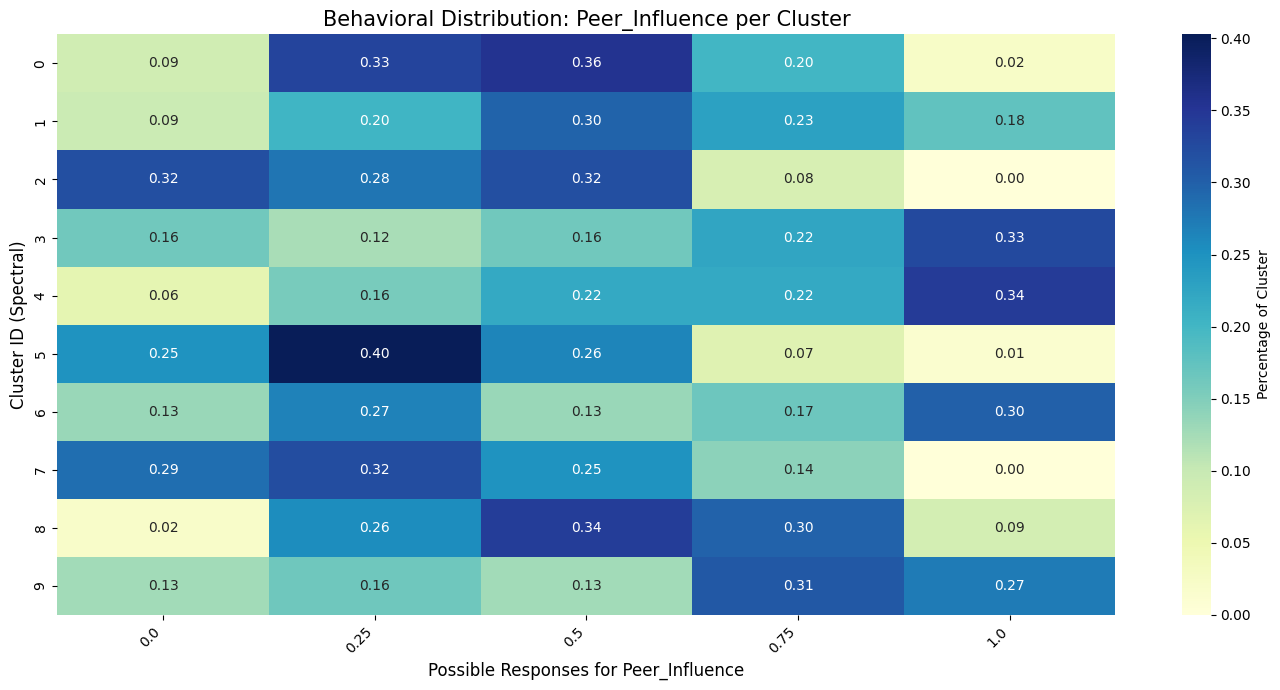

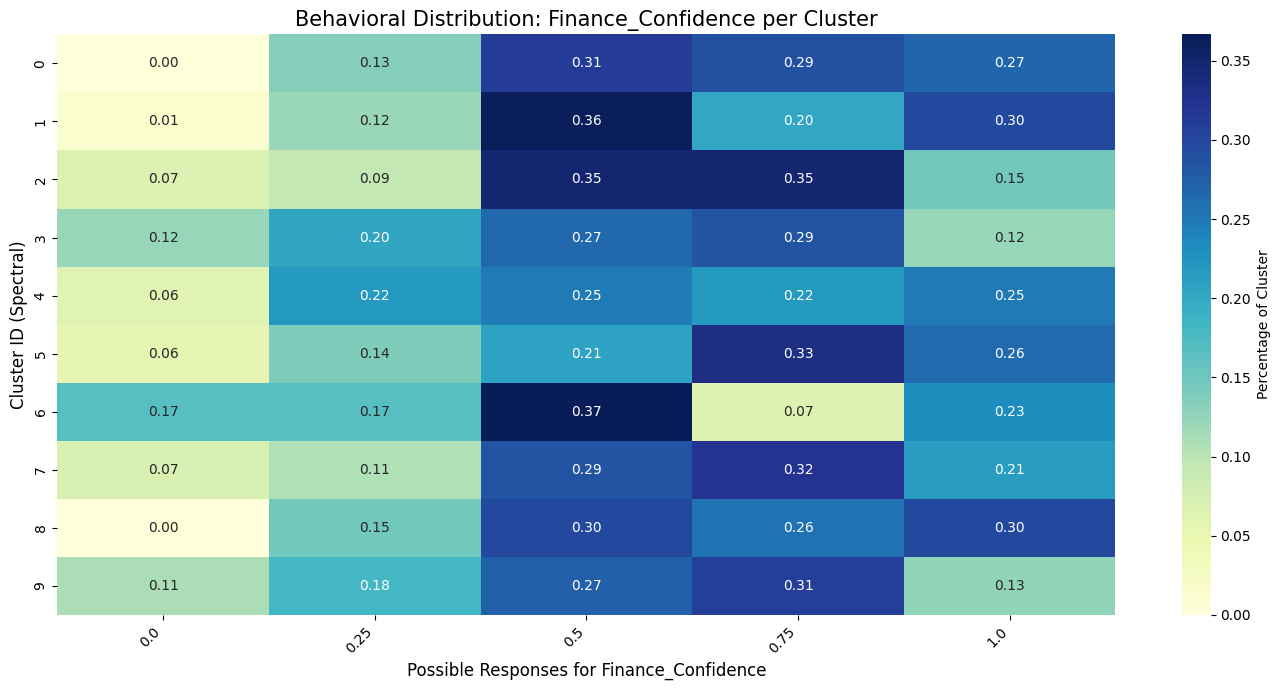

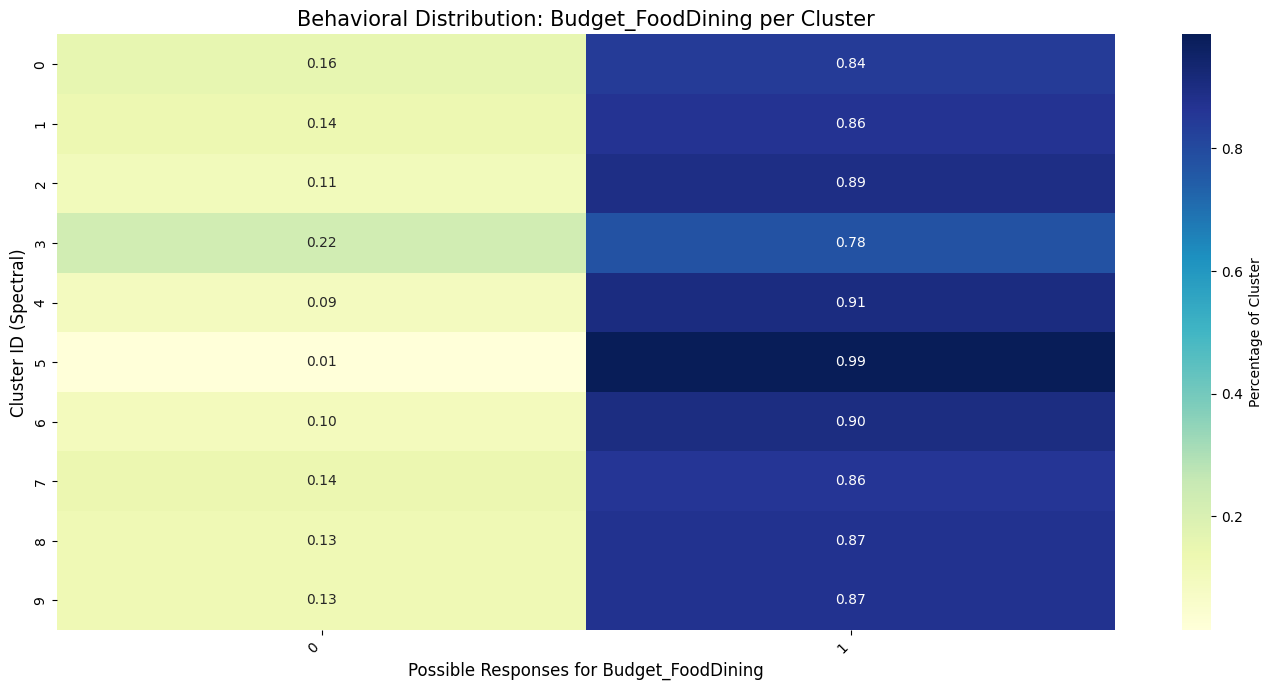

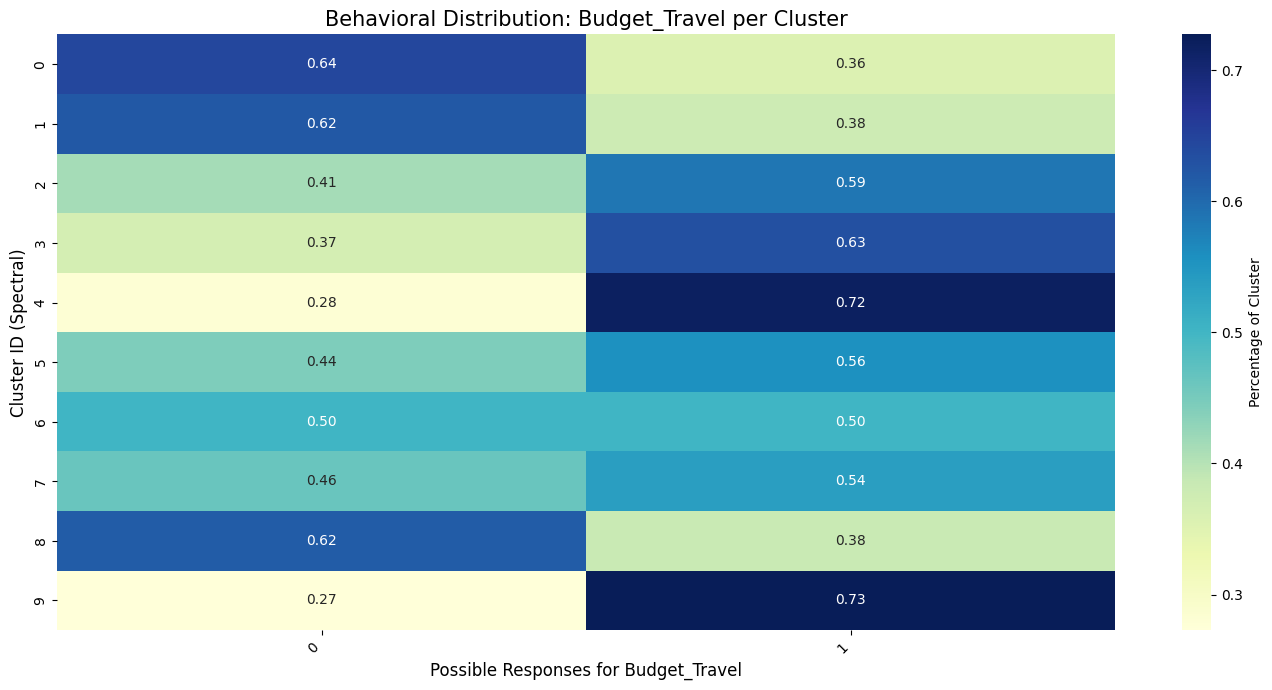

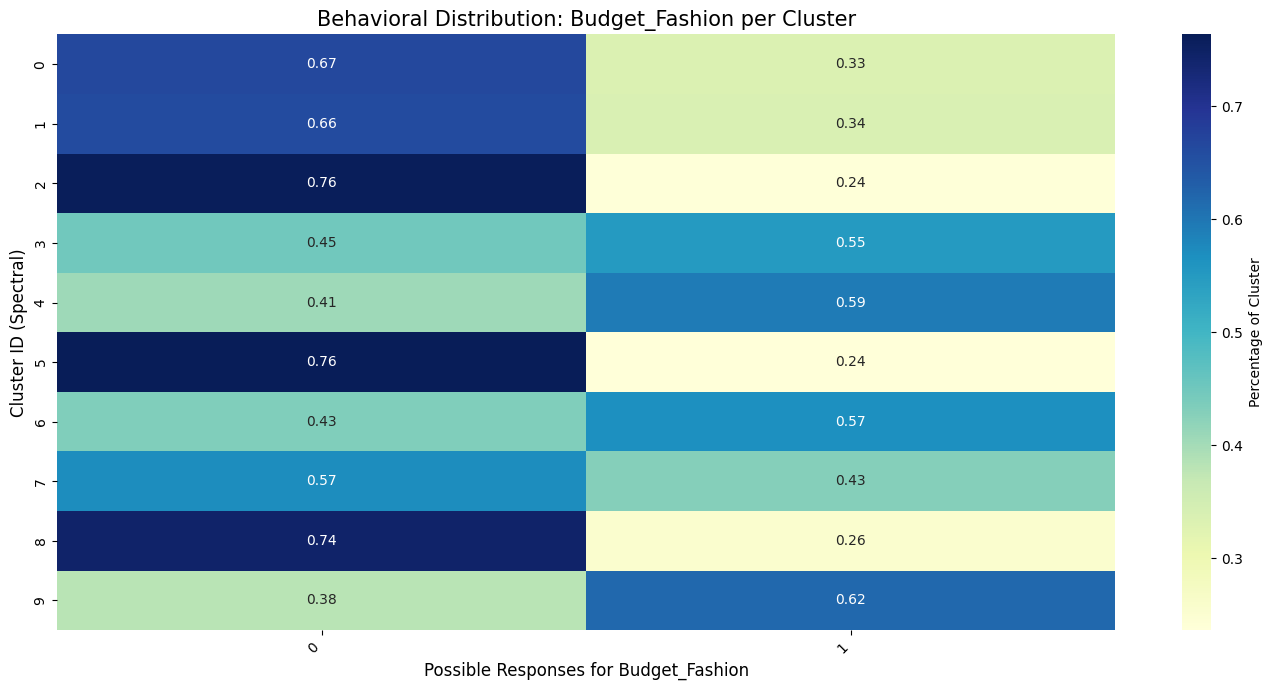

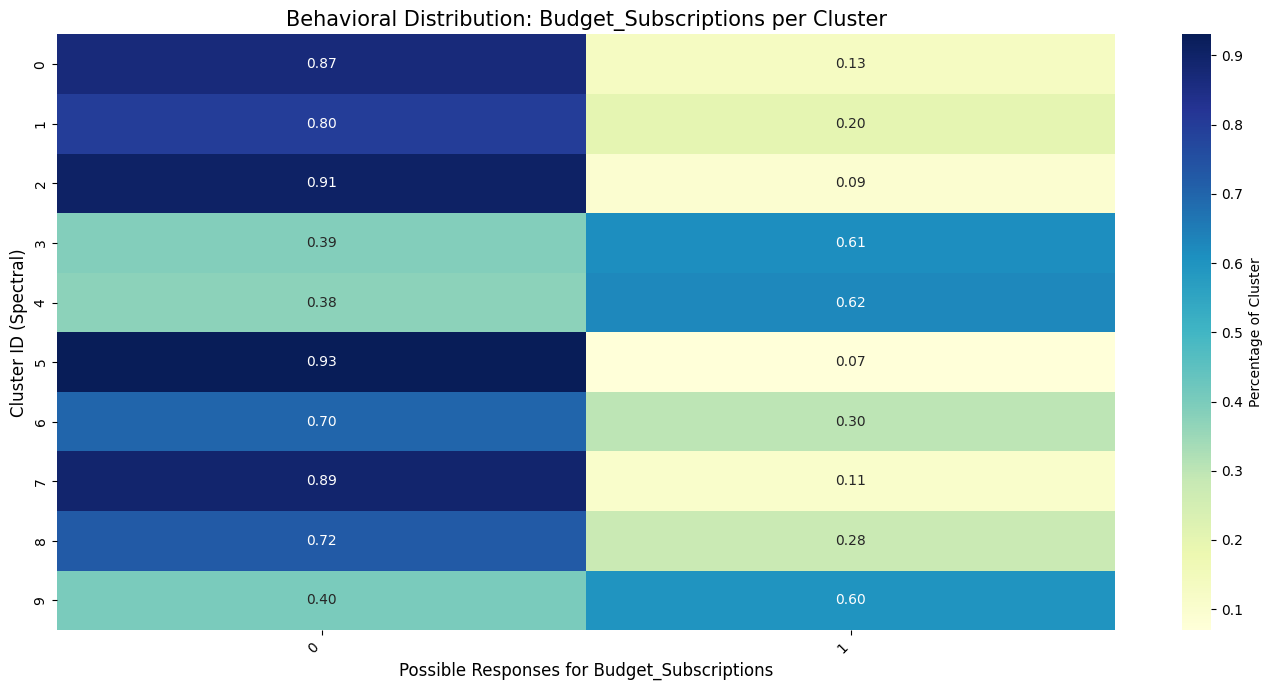

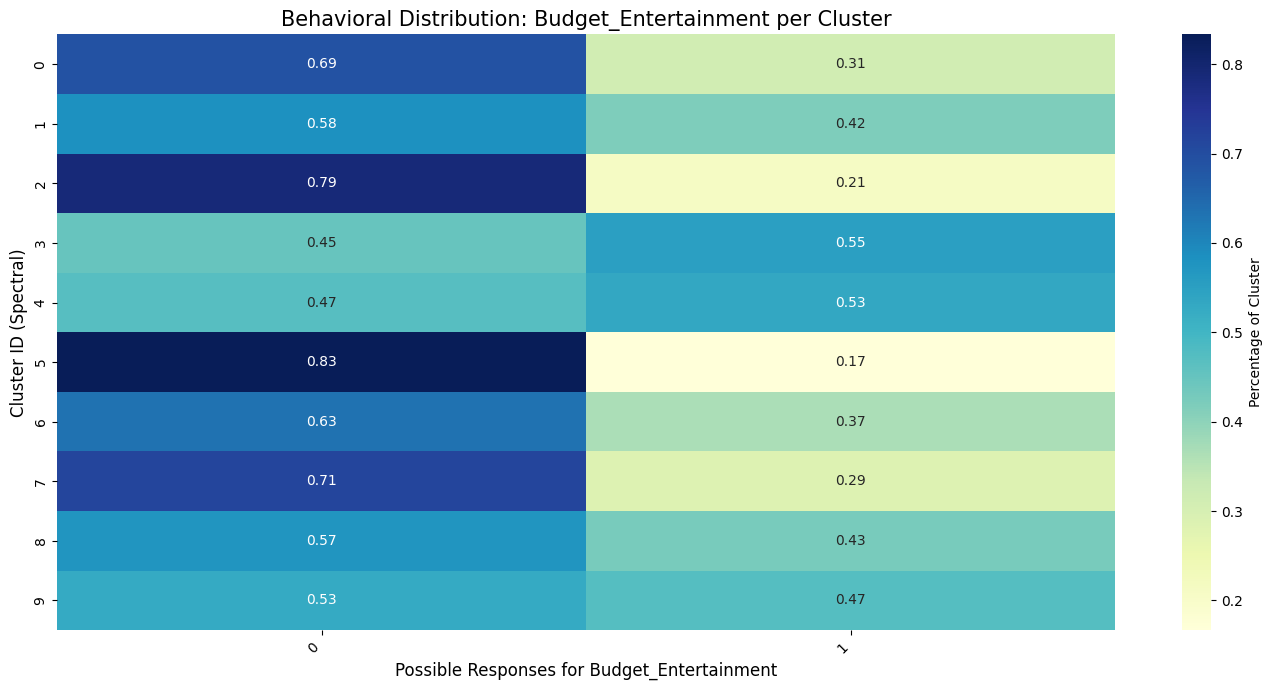

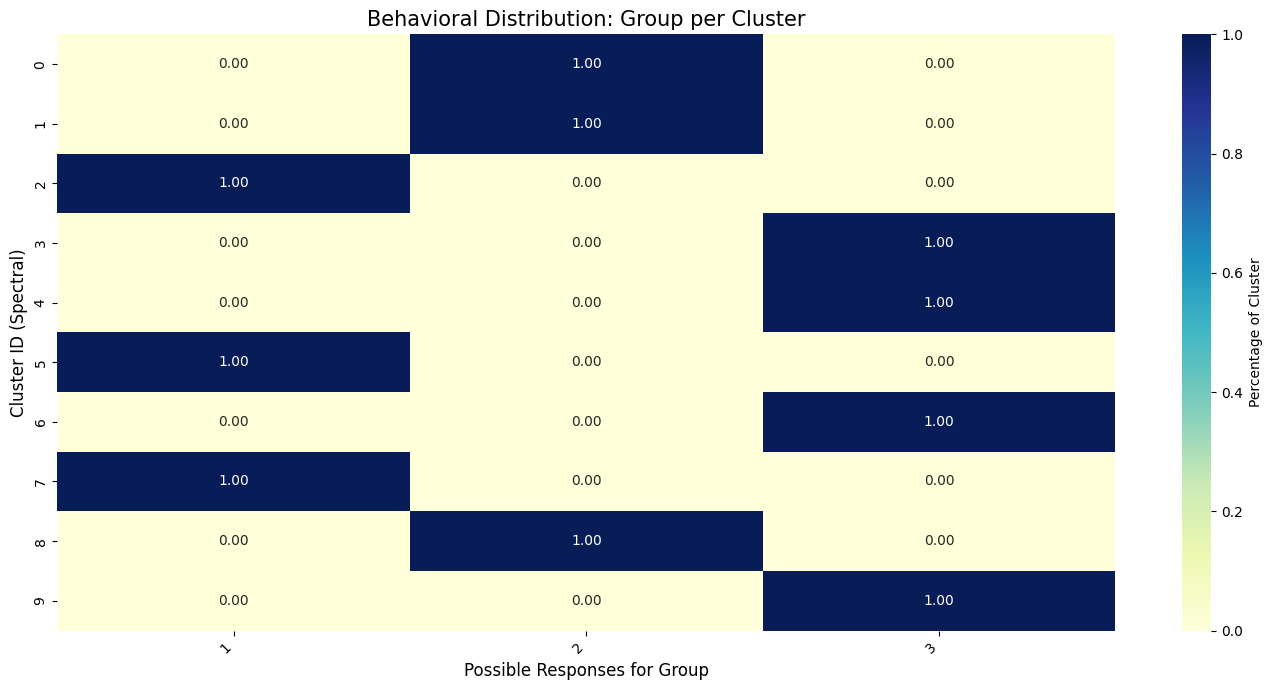

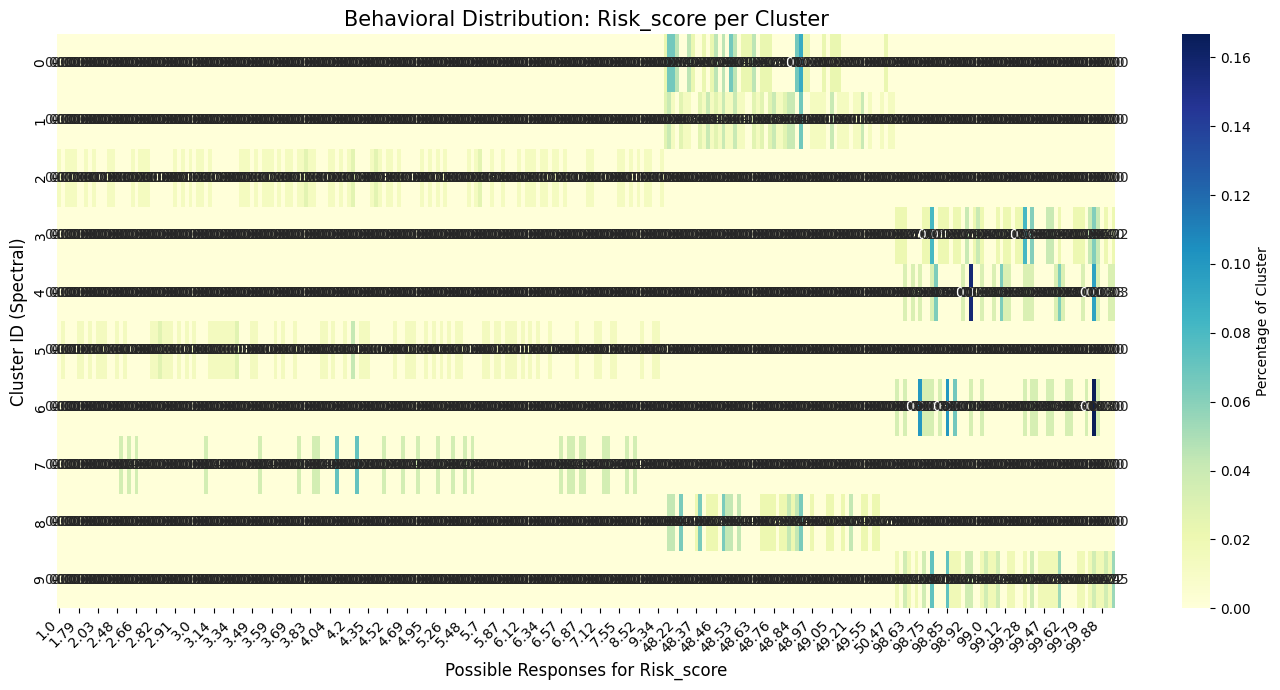

All Heatmaps generated. You can now compare the 'Heat' across clusters for each parameter.


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
import numpy as np

# 1. Load Data
# data = pd.read_csv('your_file.csv') 

# 2. Winning Model Setup (Spectral k=10)
# Ensure only numeric features are used for the affinity matrix calculation
X = data.select_dtypes(include=[np.number]).drop(columns=['Monthly_Spend', 'Price_Importance'], errors='ignore')
spectral = SpectralClustering(n_clusters=10, affinity='nearest_neighbors', random_state=42, n_init=10)
data['Cluster'] = spectral.fit_predict(X)

# 3. Comprehensive Heatmap Generation
# We will iterate through every column to see how it distributes across clusters
all_columns = [col for col in data.columns if col not in ['Cluster', 'Timestamp']]

for col in all_columns:
    # Create a contingency table (Crosstab)
    # Normalizing by 'index' (cluster) allows us to see the % composition of each cluster
    # This shows the probability: P(Feature Value | Cluster)
    analysis_matrix = pd.crosstab(data['Cluster'], data[col], normalize='index')
    
    plt.figure(figsize=(14, 7))
    sns.heatmap(analysis_matrix, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Percentage of Cluster'})
    
    plt.title(f"Behavioral Distribution: {col} per Cluster", fontsize=15)
    plt.ylabel("Cluster ID (Spectral)", fontsize=12)
    plt.xlabel(f"Possible Responses for {col}", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    # Save or show
    # plt.savefig(f'Heatmap_{col}.png')
    plt.show()

print("All Heatmaps generated. You can now compare the 'Heat' across clusters for each parameter.")